## RandomForestClassifier

In [1]:
# Load Files
import joblib
import numpy as np
from pathlib import Path

output_dir = Path("Data/processed_outputs")

X_train = joblib.load(output_dir / "X_train_supervised.pkl")
y_train = joblib.load(output_dir / "y_train_supervised.pkl")
X_val   = joblib.load(output_dir / "X_val_supervised.pkl")
y_val   = joblib.load(output_dir / "y_val_supervised.pkl")
X_test  = joblib.load(output_dir / "X_test_supervised.pkl")
y_test  = joblib.load(output_dir / "y_test_supervised.pkl")
le              = joblib.load(output_dir / "label_encoder_supervised.pkl")
class_weight_dict = joblib.load(output_dir / "class_weights_supervised.pkl")

print("Files loaded successfully")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {list(le.classes_)}")

Files loaded successfully
X_train : (580313, 20)
X_val   : (117651, 20)
X_test  : (117651, 20)
Classes : ['Bot', 'DDoS', 'DoS-GoldenEye', 'DoS-Hulk', 'DoS-SlowHTTPTest', 'DoS-Slowloris', 'FTP-BruteForce', 'PortScan', 'SSH-BruteForce', 'Web-Attack']


In [2]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=40,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight=class_weight_dict,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:   18.3s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:   44.0s finished


RandomForestClassifier(class_weight={0: 3.8484846475230454,
                                     1: 0.2820421474187622,
                                     2: 1.605602744653183,
                                     3: 0.40203750788053455,
                                     4: 3.8687533333333333, 5: 5.93731328013096,
                                     6: 3.8687533333333333,
                                     7: 0.9148440086390365,
                                     8: 0.8821089272956664, 9: 5.80313},
                       max_depth=40, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=400, n_jobs=-1, random_state=42, verbose=1)

In [3]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_val_pred = rf_model.predict(X_val)

print("Validation Results:")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=le.classes_,
    digits=4
))

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.3s


Validation Results:
                  precision    recall  f1-score   support

             Bot     0.9997    0.9997    0.9997      3231
            DDoS     0.9965    0.9836    0.9900     44090
   DoS-GoldenEye     0.9169    0.9796    0.9472      7745
        DoS-Hulk     0.9981    0.9960    0.9970     30931
DoS-SlowHTTPTest     0.9936    0.9885    0.9910       784
   DoS-Slowloris     0.9995    0.9962    0.9978      2095
  FTP-BruteForce     0.9923    0.9969    0.9946       646
        PortScan     0.9997    0.9994    0.9996     13593
  SSH-BruteForce     0.9999    1.0000    1.0000     14097
      Web-Attack     0.7772    0.9772    0.8658       439

        accuracy                         0.9912    117651
       macro avg     0.9673    0.9917    0.9783    117651
    weighted avg     0.9917    0.9912    0.9913    117651



[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.7s finished


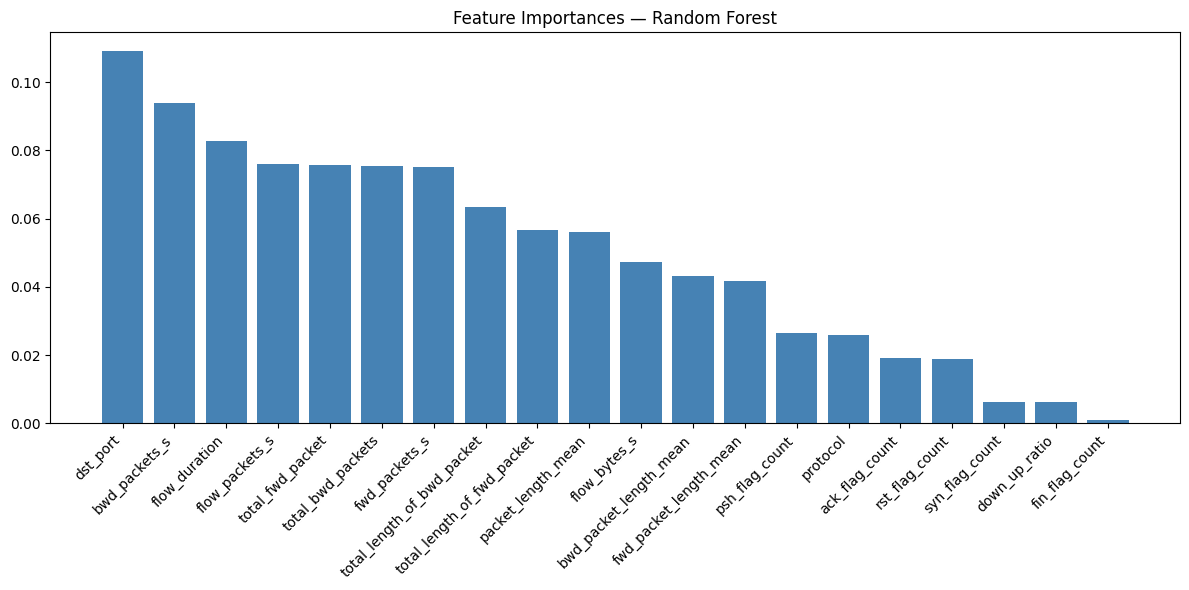

In [4]:
feature_names = joblib.load(output_dir / "scaler_supervised.pkl").feature_names_in_ \
    if hasattr(joblib.load(output_dir / "scaler_supervised.pkl"), 'feature_names_in_') \
    else [f"feature_{i}" for i in range(X_train.shape[1])]

importances = rf_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[sorted_idx], color='steelblue')
plt.xticks(range(20), [feature_names[i] for i in sorted_idx], rotation=45, ha='right')
plt.title("Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.7s finished


Test Set Results:
                  precision    recall  f1-score   support

             Bot     0.9997    0.9997    0.9997      3232
            DDoS     0.9969    0.9836    0.9902     44090
   DoS-GoldenEye     0.9170    0.9815    0.9482      7745
        DoS-Hulk     0.9979    0.9963    0.9971     30931
DoS-SlowHTTPTest     0.9822    0.9860    0.9841       784
   DoS-Slowloris     0.9976    0.9971    0.9974      2094
  FTP-BruteForce     0.9938    0.9845    0.9891       647
        PortScan     0.9999    0.9993    0.9996     13592
  SSH-BruteForce     0.9999    0.9999    0.9999     14097
      Web-Attack     0.7901    0.9772    0.8737       439

        accuracy                         0.9913    117651
       macro avg     0.9675    0.9905    0.9779    117651
    weighted avg     0.9918    0.9913    0.9914    117651



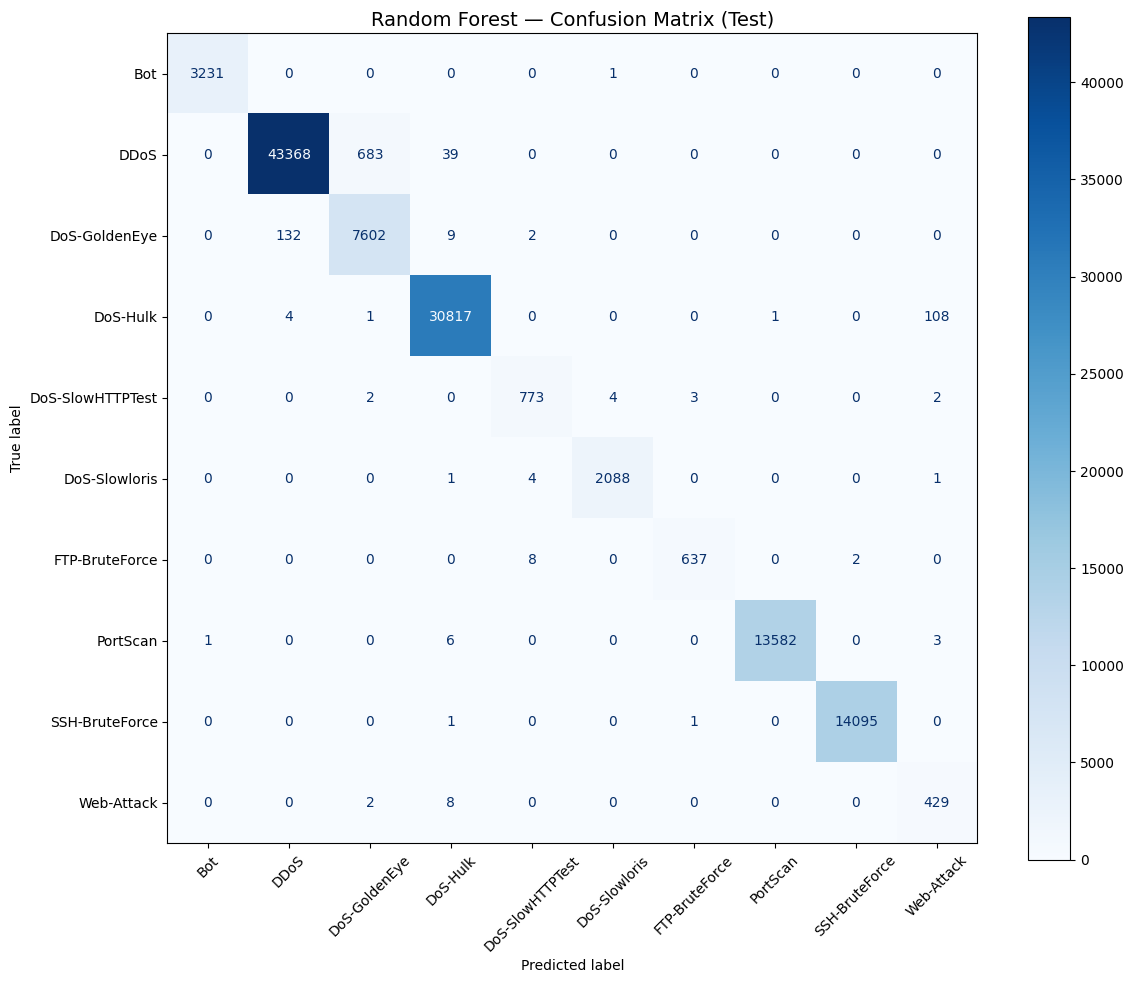

In [5]:
y_test_pred = rf_model.predict(X_test)

print("Test Set Results:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_,
    digits=4
))

cm_test = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=le.classes_
)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title("Random Forest — Confusion Matrix (Test)", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score
)

results = {
    "Accuracy"         : accuracy_score(y_test, y_test_pred),
    "Macro F1"         : f1_score(y_test, y_test_pred, average='macro'),
    "Macro Precision"  : precision_score(y_test, y_test_pred, average='macro'),
    "Macro Recall"     : recall_score(y_test, y_test_pred, average='macro'),
    "Weighted F1"      : f1_score(y_test, y_test_pred, average='weighted'),
}

print("Final Test Metrics:")
for metric, value in results.items():
    print(f"  {metric:<20} {value:.4f}")

Final Test Metrics:
  Accuracy             0.9913
  Macro F1             0.9779
  Macro Precision      0.9675
  Macro Recall         0.9905
  Weighted F1          0.9914


In [7]:
from sklearn.metrics import f1_score, accuracy_score

y_train_pred = rf_model.predict(X_train)
y_val_pred   = rf_model.predict(X_val)
y_test_pred  = rf_model.predict(X_test)

print("Overfitting Check — Score Comparison:")
print(f"{'Split':<10} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 45)
for name, y_true, y_pred in [
    ("Train", y_train, y_train_pred),
    ("Val",   y_val,   y_val_pred),
    ("Test",  y_test,  y_test_pred),
]:
    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')
    wf1  = f1_score(y_true, y_pred, average='weighted')
    print(f"{name:<10} {acc:>10.4f} {mf1:>10.4f} {wf1:>12.4f}")

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    1.8s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    4.1s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.6s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.7s finished


Overfitting Check — Score Comparison:
Split        Accuracy   Macro F1  Weighted F1
---------------------------------------------
Train          0.9938     0.9922       0.9939
Val            0.9912     0.9783       0.9913
Test           0.9913     0.9779       0.9914


In [8]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test, y_test_pred,
    target_names=le.classes_,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).T.iloc[:-3]
report_df = report_df.sort_values('recall', ascending=True)

print("Per-Class Metrics (sorted by Recall):")
print(report_df[['precision', 'recall', 'f1-score', 'support']].to_string())

Per-Class Metrics (sorted by Recall):
                  precision    recall  f1-score  support
Web-Attack         0.790055  0.977221  0.873727    439.0
DoS-GoldenEye      0.917008  0.981536  0.948176   7745.0
DDoS               0.996874  0.983624  0.990205  44090.0
FTP-BruteForce     0.993760  0.984544  0.989130    647.0
DoS-SlowHTTPTest   0.982211  0.985969  0.984087    784.0
DoS-Hulk           0.997928  0.996314  0.997120  30931.0
DoS-Slowloris      0.997611  0.997135  0.997373   2094.0
PortScan           0.999926  0.999264  0.999595  13592.0
Bot                0.999691  0.999691  0.999691   3232.0
SSH-BruteForce     0.999858  0.999858  0.999858  14097.0


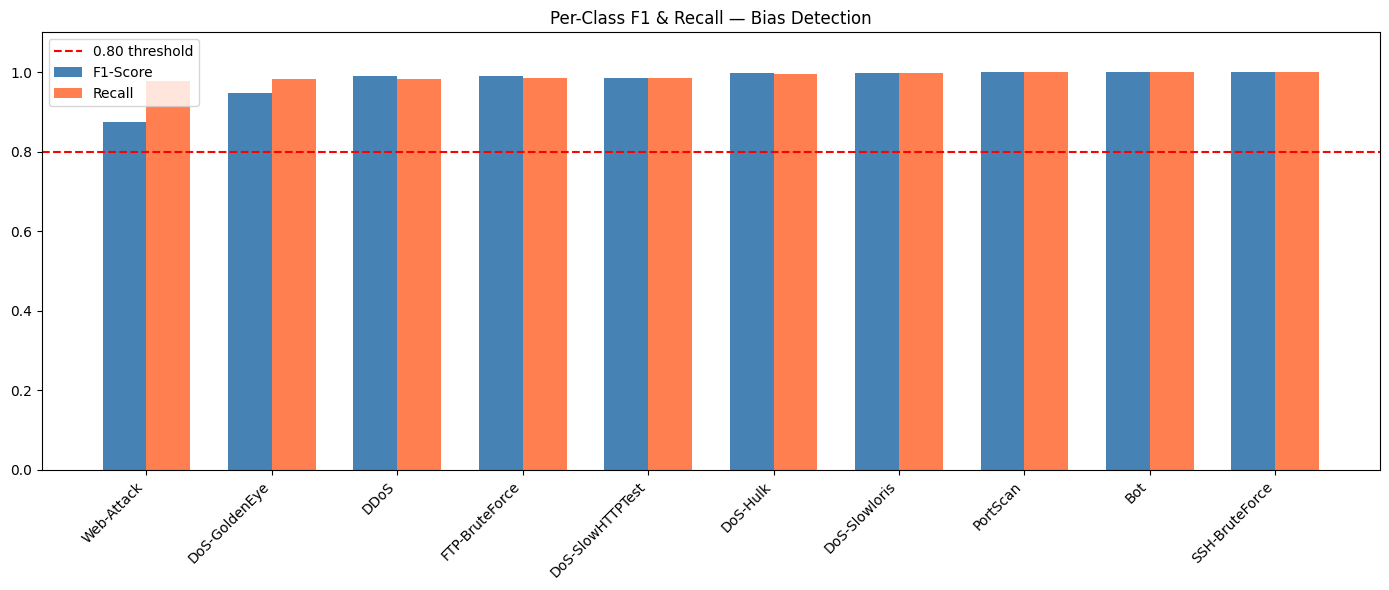

In [9]:
import matplotlib.pyplot as plt
import numpy as np

classes   = list(report_df.index)
f1_scores = list(report_df['f1-score'])
recalls   = list(report_df['recall'])

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='steelblue')
ax.bar(x + width/2, recalls,   width, label='Recall',   color='coral')
ax.axhline(y=0.80, color='red', linestyle='--', label='0.80 threshold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_title("Per-Class F1 & Recall — Bias Detection")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
import joblib
import os

project_root = os.path.abspath(os.path.join(os.getcwd()))
models_path  = os.path.join(project_root, "Models")
os.makedirs(models_path, exist_ok=True)

# Save Predictions
y_pred_train = rf_model.predict(X_train)
y_pred_val   = rf_model.predict(X_val)
y_pred_test  = rf_model.predict(X_test)

joblib.dump(y_pred_train, os.path.join(models_path, "rf_preds_train.pkl"))
joblib.dump(y_pred_val,   os.path.join(models_path, "rf_preds_val.pkl"))
joblib.dump(y_pred_test,  os.path.join(models_path, "rf_preds_test.pkl"))

# Save Model
joblib.dump(rf_model, os.path.join(models_path, "rf_model.pkl"))

# Save Probability Scores (equivalent to decision_function in iso_forest)
train_scores = rf_model.predict_proba(X_train)
val_scores   = rf_model.predict_proba(X_val)
test_scores  = rf_model.predict_proba(X_test)

joblib.dump(train_scores, os.path.join(models_path, "rf_train_scores.pkl"))
joblib.dump(val_scores,   os.path.join(models_path, "rf_val_scores.pkl"))
joblib.dump(test_scores,  os.path.join(models_path, "rf_test_scores.pkl"))

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    1.6s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    3.9s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.7s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 400 out of 400 | elapsed:    0.6s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Do

['c:\\AI_Cybersecurity\\Models\\rf_test_scores.pkl']